# ADP 27회

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import koreanize_matplotlib

warnings.filterwarnings('ignore')

## 1 데이터 확인 및 전처리

In [11]:
d1= pd.read_csv('https://raw.githubusercontent.com/TKV-JONGIN/DataSet/refs/heads/main/ADP_27%ED%9A%8C_1%EB%B2%88_5%EB%B2%88%EC%9A%A9.csv')
d1.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,Amount,Class
0,60.0,1.069141,0.043786,0.309867,1.316694,-0.462394,-0.857888,0.207904,-0.191270,0.056398,0.041567,-0.507358,-0.108666,-0.473257,0.452046,1.005675,0.185441,-0.439976,89.40,0
1,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,-2.772272,3.202033,-2.899907,-0.595222,-4.289254,0.389724,-1.140747,-2.830056,0.00,1
2,426.0,-1.932055,1.724618,1.288229,-0.396998,-0.140202,2.470521,-1.865298,-5.186855,0.794764,0.155379,0.034517,0.906738,-0.027172,-0.404303,-0.473949,0.274034,-0.222340,16.19,0
3,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,-0.414575,-0.503141,0.676502,-1.692029,2.000635,0.666780,0.599717,529.00,1
4,674.0,-0.719065,0.638954,0.686335,-0.023240,2.317890,3.871978,-0.312797,1.089780,-0.596925,-0.006142,-0.242883,-0.384491,0.109079,0.187565,1.823472,0.274346,-0.697730,22.00,0


## 1.1 
EDA 데이터 탐색하세요.

In [12]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1193 entries, 0 to 1192
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1193 non-null   float64
 1   V1      1193 non-null   float64
 2   V2      1193 non-null   float64
 3   V3      1193 non-null   float64
 4   V4      1193 non-null   float64
 5   V5      1193 non-null   float64
 6   V6      1193 non-null   float64
 7   V7      1193 non-null   float64
 8   V8      1193 non-null   float64
 9   V9      1193 non-null   float64
 10  V10     1193 non-null   float64
 11  V11     1193 non-null   float64
 12  V12     1193 non-null   float64
 13  V13     1193 non-null   float64
 14  V14     1193 non-null   float64
 15  V15     1193 non-null   float64
 16  V16     1193 non-null   float64
 17  V17     1193 non-null   float64
 18  Amount  1193 non-null   float64
 19  Class   1193 non-null   int64  
dtypes: float64(19), int64(1)
memory usage: 186.5 KB


모두 연속형 변수(20)이며 결측치가 없는 것을 확인할 수 있다.  
여기서 class는 종속변수이다.  
다음으로 데이터의 분포를 시각화를 포함하여 수행한다.

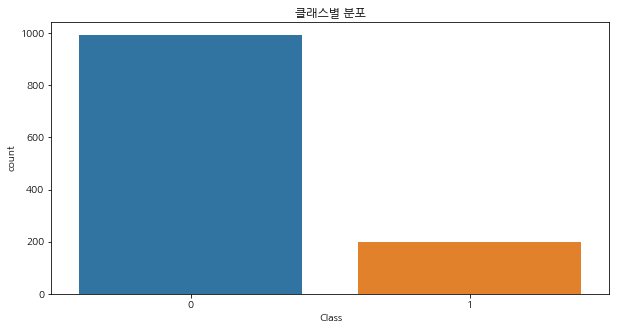

In [14]:
# 먼저 class 의 분포를 count plot으로 확인(카테고리 데이터)

plt.figure(figsize=(10, 5))
sns.countplot(d1['Class'])
plt.title('클래스별 분포')
plt.show()

In [17]:
d1['Class'].value_counts()

0    993
1    200
Name: Class, dtype: int64

In [16]:
d1['Class'].value_counts(normalize=True)

0    0.832355
1    0.167645
Name: Class, dtype: float64

이진 클래스이다. 클래스가 0인 데이터가 확연히 많으므로(약 88:17) 추후 해당 데이터를 가지고 분류모델을  
학습한다면 불균형 데이터에 대한 전처리가 필요할 것이다.   

다음으로 각 설명변수에 대한 분포를 알아본다.

In [20]:
d1.describe()[:-1].T

,count,mean,std,min,25%,50%,75%
Time,1193.0,91514.485331,47896.081947,60.000000,50265.000000,81797.000000,136995.000000
V1,1193.0,-0.755027,3.622262,-30.552380,-1.302600,-0.302521,1.249960
V2,1193.0,0.543730,2.663928,-33.644637,-0.435358,0.231973,1.112040
V3,1193.0,-1.148224,3.908787,-31.103685,-1.609339,-0.234204,0.811507
V4,1193.0,0.777816,2.345566,-4.294888,-0.610310,0.327567,1.335332
V5,1193.0,-0.409181,2.702077,-22.105532,-0.842184,-0.073622,0.684224
V6,1193.0,-0.283953,1.507579,-10.886820,-1.017863,-0.379633,0.302350
V7,1193.0,-0.852545,3.396565,-37.060311,-0.806043,-0.084983,0.464553
V8,1193.0,0.145026,2.471559,-37.353443,-0.219328,0.073036,0.454794
V9,1193.0,-0.446390,1.664075,-11.126624,-1.039740,-0.210455,0.452561


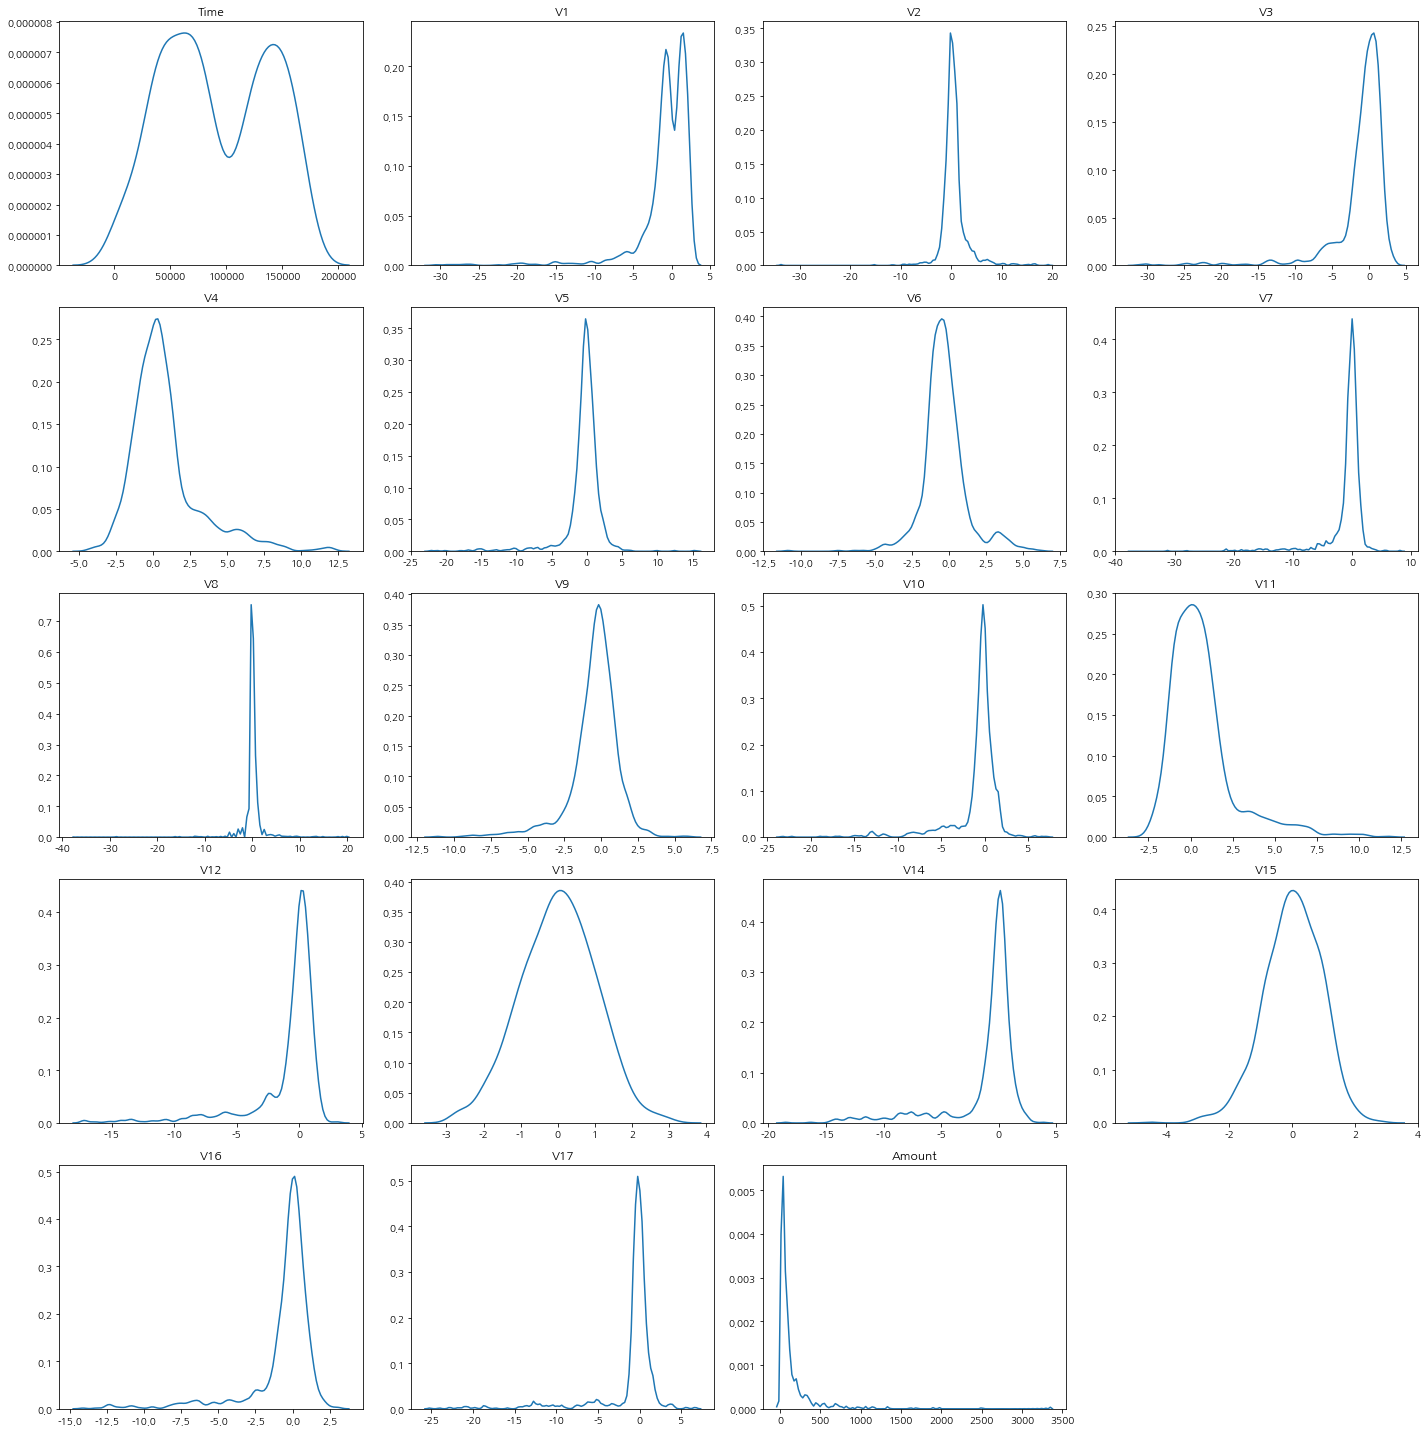

In [28]:
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
c_names = d1.columns[:-1]

for col, ax in zip(c_names, axes.flatten()):
    sns.kdeplot(data=d1[col], ax=ax, legend=False)
    ax.set_title(col)
plt.tight_layout()
axes[4, 3].remove()
plt.show()

- time은 쌍봉분포를 보이며, 5만과 15만 구간에 집중되어 있음  
- v4, 11, amount는 오른쪽으로 꼬리가 긴 양의 왜도  
- v13, 15는 평균이 0이며, 분산이 1인 정규분포에 가까운 분포를 보임
- v2, 8 등의 변수는 첨도가 높아서 특정 값에 분포가 집중되어 있음  
나머지 변수들은 대체로 음의 왜도를 보임

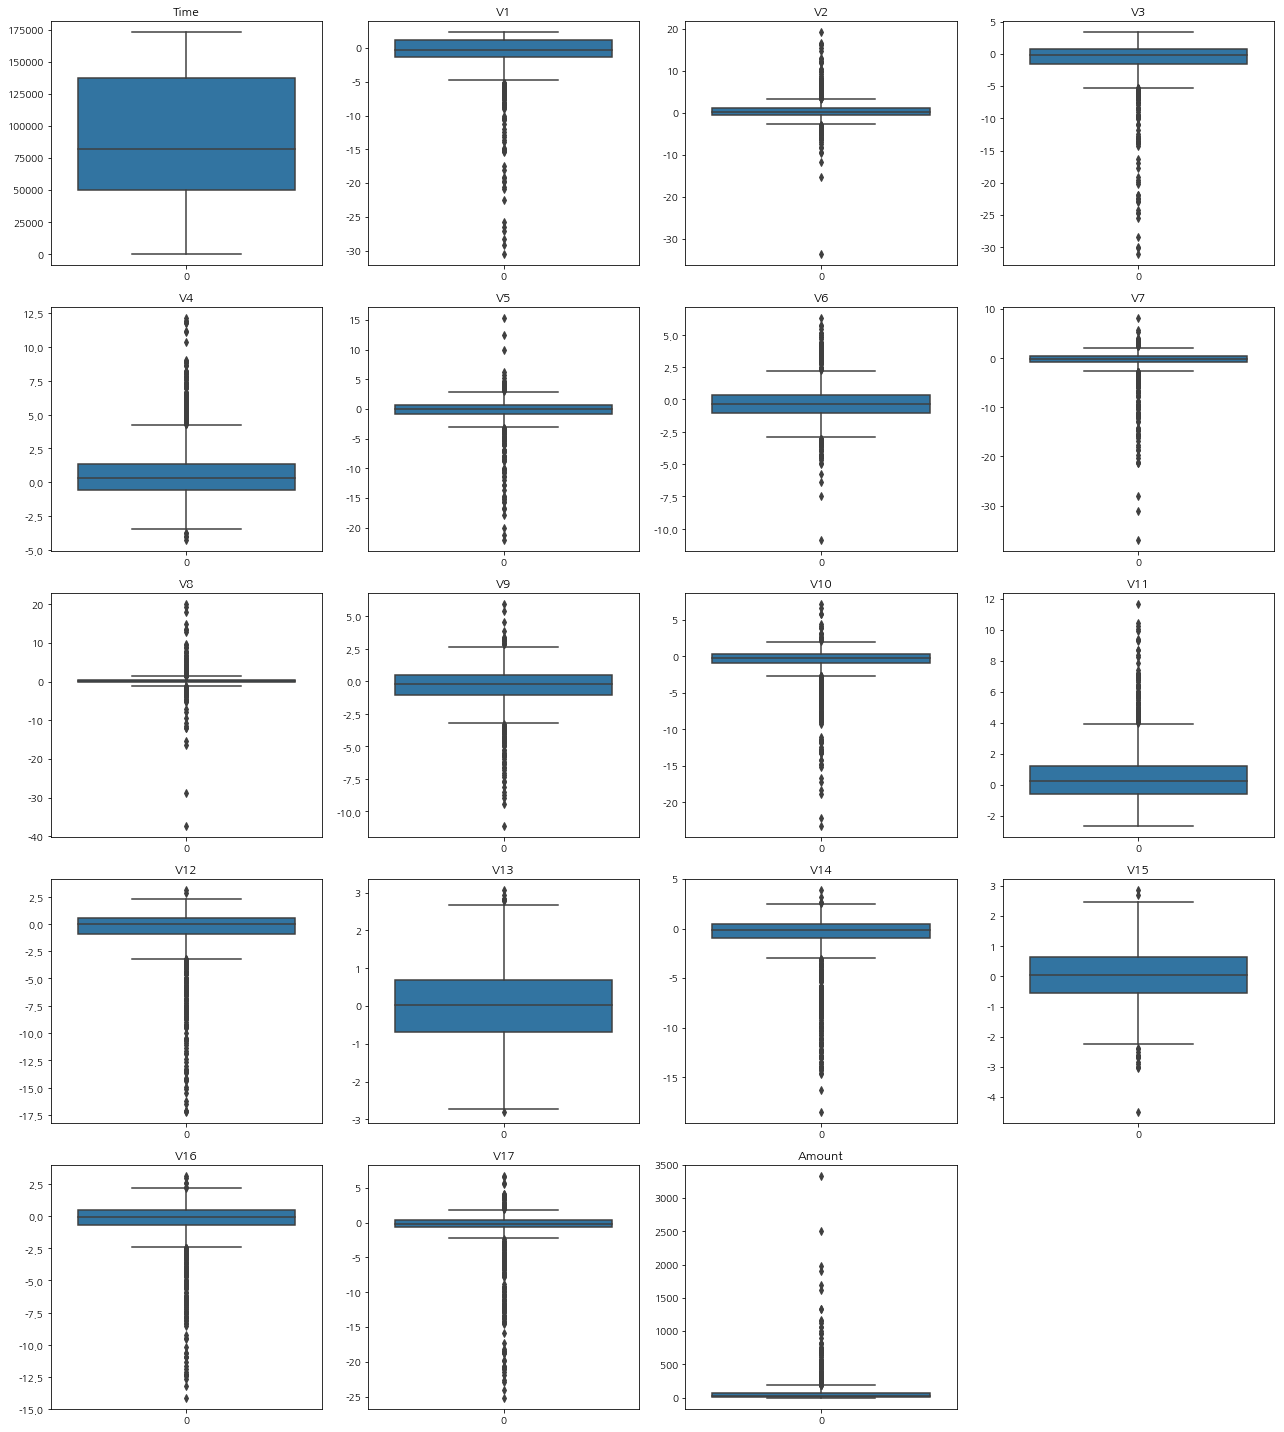

In [36]:
fig, axes = plt.subplots(5, 4, figsize=(18, 20))
c_names = d1.columns[:-1]

for col, ax in zip(c_names, axes.flatten()):
    sns.boxplot(data=d1[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
axes[4, 3].remove()
plt.show()

결측치는 없으며, 이상치에 대한 판별은 iqr, zscore+-3 방식으로 확인할 수는 있으나, 데이터에 대한 지식이 없으므로  
측정한 값에 대한 이상치 여부를 확인할 수 없다. 따라서 생략한다.

## 1.2 
변수간 상관관계를 시각화하고 전처리가 필요함을 설명하라

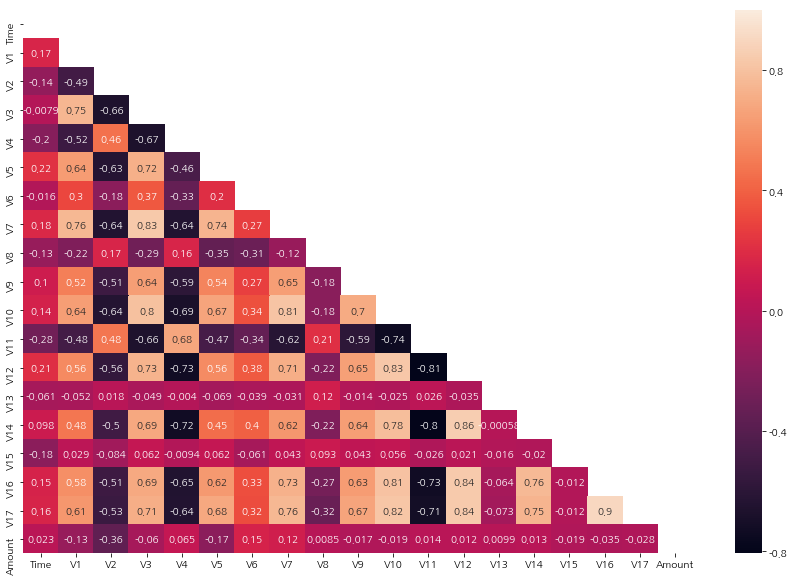

In [47]:
corr = d1.iloc[:, :-1].corr()

plt.figure(figsize=(15, 10))
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True)
plt.show()

In [51]:
corr_filtered = corr.where(np.abs(corr) >= 0.6)
display(corr_filtered)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,Amount
Time,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V1,NaN,1.000000,NaN,0.747294,NaN,0.639808,NaN,0.759509,NaN,NaN,0.640838,NaN,NaN,NaN,NaN,NaN,NaN,0.613414,NaN
V2,NaN,NaN,1.000000,-0.662717,NaN,-0.626978,NaN,-0.641787,NaN,NaN,-0.635937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V3,NaN,0.747294,-0.662717,1.000000,-0.669457,0.721634,NaN,0.830995,NaN,0.640404,0.800687,-0.661869,0.734679,NaN,0.689142,NaN,0.691389,0.711412,NaN
V4,NaN,NaN,NaN,-0.669457,1.000000,NaN,NaN,-0.638917,NaN,NaN,-0.686783,0.676151,-0.727734,NaN,-0.724656,NaN,-0.650353,-0.642360,NaN
V5,NaN,0.639808,-0.626978,0.721634,NaN,1.000000,NaN,0.743969,NaN,NaN,0.670030,NaN,NaN,NaN,NaN,NaN,0.624204,0.683379,NaN
V6,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V7,NaN,0.759509,-0.641787,0.830995,-0.638917,0.743969,NaN,1.000000,NaN,0.645007,0.810600,-0.617405,0.713087,NaN,0.617465,NaN,0.731554,0.759977,NaN
V8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V9,NaN,NaN,NaN,0.640404,NaN,NaN,NaN,0.645007,NaN,1.000000,0.702023,NaN,0.652466,NaN,0.640872,NaN,0.634698,0.674207,NaN


선형 상관분석인 피어슨 상관계분석을 통해 각 변수 간의 상관관계를 확인하였다.  
일반적으로 비교적 강한 상관관계 기준인 0.6을 기준으로 보았을 때 상당히 많은 변수 간 상관관계를 확인할 수 있다.  
피어슨 상관관계는 각 변수들 간 1:1 선형관계만 확인하기 때문에 vif를 통해 1:n 상관관계까지 확인 후 다중공선성 여부를 결정한다.  

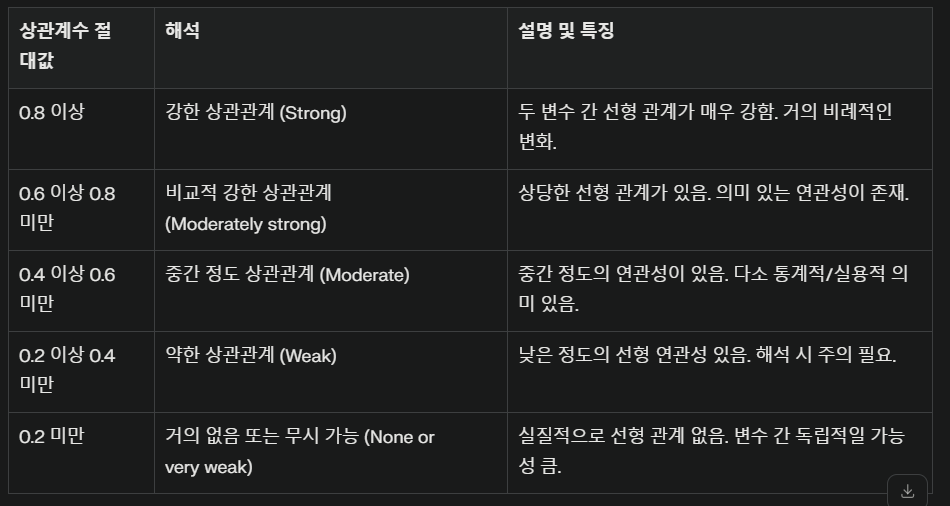

In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['name'] = c_names
vif['vif'] = [variance_inflation_factor(d1[c_names], i) for i in range(len(c_names))]
display(vif[vif['vif']>=5].reset_index(drop=True))

,name,vif
0,V3,6.845459
1,V5,6.076872
2,V7,10.885920
3,V10,6.908535
4,V12,7.965567
5,V14,6.070439
6,V16,6.974822
7,V17,8.702978


일반적으로 vif는 10 이상일 시 강한 다중공선성을 가지며, 5~10 사이의 값은  
문제가 있다고 보며 변수 재선택이 권장된다.  
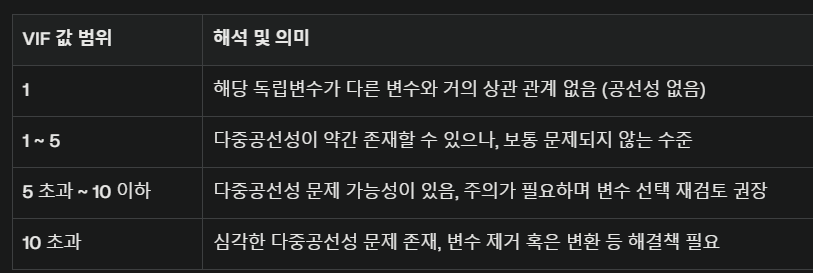

v7은 강한 다중공선성을 가지고 있으며, v3 등 6개의 변수에서 비교적 강한 다중공선성을 보인다.   

다중공선성이 높다는 것은 설명변수들 간 높은 상관관계를 가진다는 것을 뜻하며,  
이는 모델의 예측 안정성과 해석 가능성을 저하시킬 수 있으므로 PCA(주성분 분석)나  
변수 선택 기법 등을 통한 차원축소가 필요하다.

## 2 차원축소 (1번이어서)

### 2.1 차원축소 방법 2가지 이상 비교하고 한가지 선택하세요. 

주성분 분석(PCA)과 선형판별분석(LDA)를 비교한다.   
- PCA(비지도학습): 데이터의 분산을 최대한 보존하는 방향으로 새로운 축(주성분)을 찾아 상관관계가 있는 변수들을 새로운 축에 직교화 된  
  축으로 변환하여 중복을 제거하는 방식, 구현이 간편하며 각 변수들 간 설명력 정도를 직관적으로 확인이 가능하다는 장점이 있다.  
  (선형대수의  SVD 분해를 사용한다.)
- LDA(지도학습): 클래스 간 분리를 최대화하고, 클래스 내 분산을 최소화하는 축을 찾는다. 클래스 정보를 반영하여 반영하여 분류성능이  
  높은 저차원데이터로 모델학습을 수행한다.   
  (충분하고 균형 잡힌 레이블 데이터가 있을 때 뛰어난 분류 성능과 차원 축소 효과를 보임)  


여기서는 PCA를 선택한다.

### 2.2 추천한 한 가지를 실제로 수행하고 선택한 이유 설명

해당문제는 레이블이 불균형하여 클래스 간 분리 설명모델보다는, 데이터 자체를 적절히 잘 설명하는 저차원 모델이 필요하므로 PCA를 활용  

PCA는 각 변수 간 거리에 민감한 기법이므로 스케일링(여기서는 standard scaler)을 수행하며, 데이터 누수(leak)를 예방하기 위해  
train, test set 으로 분할 → PCA를 수행한다.

## 3 오버샘플링/언더샘플링 (1번이어서)

### 3.1 오버샘플링과 언더샘플링 장단점 비교 및 선택 구현

### 3.2 구현 및 알고리즘 2가지 이상 비교, 성능 측정

### 3.3 현재까지 전처리한 데이터를 통해 모델 수행 후 결과 분석

## 4 이상탐지

### 4.1 이상탐지 모델 2가지 이상 기술, 장/단점 설명

### 4.2 2번에서 만든 데이터로 한 가지 이상탐지 모델을 구현하고, 3번에서 만든 모델과 비교

### 4.3 데이터분석가 관점에서 3번에서 만든 모델과 4번에서 만든 모델 설명

## 5  
2년 전 제품 생산량이 100,000개, 1년 전 제품 생산량이 150,000개, 그 후 팩토리 기술의 상승으로 제품 생산량이 250,000개 되었을 때, 연평균 상승률의 대푯값을 구하시오. (반올림하여 소수점 아래 둘째자리까지 표기하시오.)

In [82]:
#기하평균 문제
from scipy.stats import gmean

# 먼저 년도별 상승률을 구해야 한다. +1한 것임
df = np.array([150000, 250000])/np.array([100000, 150000])

g_mean = gmean(df)-1

print(f"연평균 상승률[기하평균]: {g_mean*100:.2f} %")

연평균 상승률[기하평균]: 58.11 %


In [87]:
#수기계산

g2 = np.prod(df)**(1/2)-1

print(f"수기계산: {g2*100:.2f} %")

수기계산: 58.11 %


## 6
12건의 광고 시간 측정. 평균 15.5초, 분산 3.2초 일때 90% 신뢰구간은?



In [99]:
from scipy.stats import t

n= 12 #12건의 광고
m = 15.5 #평균
v = 3.2 #분산
a = 0.1 #신뢰구간
dof = n-1 # 자유도

se = np.sqrt(v)/np.sqrt(n) #표본표준오차
z = t.ppf(1-a/2, dof) #단측 신뢰계수
me = se*z #허용오차

print(f"90% 신뢰구간: {m-me:.3f} ~ {m+me:.3f}")

90% 신뢰구간: 14.573 ~ 16.427


12건의 광고시간 측정으로 확인된 평균과 분산은 모집단을 대표한다고 볼 수 없으므로 표본평균, 분산으로 보아야 한다.  
따라서 t 분포를 통해 90% 신뢰구간을 구한다.  
여기서 자유도는 t 분포의 자유도인 n-1을 사용한다.  

이를 통해 표본표준오차, 신뢰계수(단측), 허용오차를 순차적으로 구하고, 표본평균에 허용오차를 -+하여 상 하단 신뢰구간을 구할 수 있다.  

## 7
강의 상류와 하류의 생물 다양성 점수에 차이가 있는지 검정하시오. (단, 같은 강에서 상류와 하류는 서로 독립적이지 않으며, 종속적인 관계에 있다.)

In [100]:
d7=pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/27/river.csv')
d7.head()

,River,up,down
0,A,57.1,45.7
1,B,51.6,37.2
2,C,53.9,53.3
3,D,59.0,54.3
4,E,57.5,46.3


In [103]:
from scipy.stats import shapiro

shapiro(d7['up'])

ShapiroResult(statistic=0.9635884165763855, pvalue=0.6447697877883911)

In [104]:
shapiro(d7['down'])

ShapiroResult(statistic=0.9821230173110962, pvalue=0.9640804529190063)

## 7.1 
귀무가설과 대립가설을 세우시오



한 강에서 상류, 하류 두 조건에 대한 데이터가 대응되므로 대응표본이다. 또한 두 대응표본간 종속적인 관계가 있으며 두 표본간   
차이여부를 확인하는 것이므로 대응표본 t-test를 사용한다. 만약 정규성을 만족하지 않는다면 비모수검정인 이표본 윌콕슨   
부호순위 검정을  사용해야 한다. 먼저 모수, 비모수 검정 여부를 확인하기 위해 정규성(shapiro) 검정을 실시한다.  
정규성의 경우 2표본 모두 정규성을 만족해야만 정규성을 만족한다고 본다.  

In [113]:
from scipy.stats import shapiro, levene

print("[정규성 검정]")
stat1, p1 = shapiro(d7['up'])
stat2, p2 = shapiro(d7['down'])

print(f"{p1:.3f}, {p2:.3f} 정규성", "만족" if (p1 >= 0.05) & (p2 >= 0.05) else "불만족")

[정규성 검정]
0.645, 0.964 정규성 만족


정규성을 만족하므로 이표본 대응표본 ttest를 실시한다.  

유의확률 5% 하에서 검정을 실시하며 가정은 다음과 같다.   
- H0: 강의 상류와 하류의 다양성 점수 차이가 없다. 
- H1: 강의 상류와 하류의 다양성 점수 차이가 있다. 

In [112]:
from scipy.stats import ttest_rel

stat, p = ttest_rel(d7['up'], d7['down'])

print(f"p-value({p:.3f}), 귀무가설", "기각(대립)" if p < 0.05 else "기각x")

p-value(0.213), 귀무가설 기각x


p-value가 0.213으로 귀무가설을 기각할 수 없다.   
따라서 강의 상 하류 간 생물 다양성 점수의 차이가 없다.

## 7.2 
검정 통계량과 유의 확률을 구하고, 연구가설 채택여부를 검정하시오.



In [102]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(d7['up'], d7['down'], zero_method='wilcox')

print(f"검정통계량: {stat}")
print(f"p-value: {p:.3f}")

검정통계량: 64.5
p-value: 0.241


유의수준 5% 하 이표본 윌콜슨 부호순위 검정결과, p-value가 0.241로 0.05보다 충분히 크므로 귀무가설을 기각할 수 없다.  
따라서 강의 상류와 하류 생물 다양성 점수에 차이가 없다.

## 8
user_counts를 종속변수로 하는 데이터이다

In [7]:
d8= pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/27/problem8.csv')
d8.head()

,temperature,wind,precipitation,user_counts
0,10.400000,4.600,0.844944,6368
1,5.666667,4.625,0.040860,5902
2,4.933333,4.725,0.008696,6226
3,3.400000,2.675,0.156989,5829
4,8.900000,3.950,7.988462,7589


## 8.1 
분위수 회귀분석 (Quantile Regression) 을 사용하여 회귀 계수를 구하시오. (반올림하여 소수점 아래 둘째자리까지 표기하시오.)

## 8.2 
8.1의 모델의 회귀계수를 활용하여 temperature : 10.5 , wind : 8.2 , precipitation : 3.5 일때 user_counts를 예측하시오

## 9
지하철 호선과 월별, 승객 수 간 상관관계가 있는지 확인(Type III Anova 사용)

In [115]:
d9= pd.read_csv('https://github.com/johyunkang/adp_certificate/files/10883822/subway.csv')
d9.head()

,line,month,total
0,1,1,1310
1,1,2,1300
2,1,3,1305
3,1,4,1200
4,1,5,1301


여기서 line, month는 독립적인 명목변수, 설명변수이며 각각 3, 12개의 그룹이 있고, total은 연속형 변수이며 종속변수이다.  

따라서 모수추정을 위한 가정을 만족한다면  모수인자가 2개이며 각각 3개 이상 집단을 가지므로 two-way anova를 사용할 수 있을 것이다. 

- 정규성: shapiro 검정 후 귀무가설 충족 시
- 독립성: 잔차분석은 가능하지만 독립적으로 수집되었다고 가정하고 만족한다고 봄
- 등분산성: levene 검정 후 귀무가설 충족 시

In [156]:
from scipy.stats import shapiro, levene
from statsmodels.stats.stattools import durbin_watson

line_g = [d9[d9['line'] == i]['total'] for i in range(1, 4)]
m_g = [d9[d9['month'] == i]['total'] for i in range(1, 12)]

s1, s2 = [], [] #샤피로
print("[정규성 검정: shapiro]")
for i, g in enumerate(line_g):
    stat, p = shapiro(g)
    s1.append(p)
for i, g in enumerate(m_g):
    stat, p = shapiro(g)
    s2.append(p)

print(f"라인: {all(s >= 0.05 for s in s1)}")
print(f"월: {all(s >= 0.05 for s in s2)}")


print("\n[등분산성 검정: levene]")
stat1, p1 = levene(*line_g)
stat2, p2 = levene(*m_g)

print(f"라인: {p1 >= 0.05}")
print(f"월: {p2 >= 0.05}")

[정규성 검정: shapiro]
라인: False
월: False

[등분산성 검정: levene]
라인: False
월: True


## 9.1 
귀무가설과 대립가설 설정하라

유의수준 5% 하에서 가설을 설정한다.  
각 독립변수의 주효과와 두 독립변수간 교호작용 효과로 나뉠 수 있는데 교호작용 효과가 유의하다면  
주효과 분석에 영향을 주므로 신중하게 접근해야 한다. 

- 귀무가설
    - 주효과1: 라인에 따라 승객수의 차이가 없다.
    - 주효과2: 월에 따라 승객수의 차이가 없다.
    - 교호: 라인과 월 별 상호작용 효과가 없다.


- 대립가설- 귀무가설
    - 주효과1: 라인에 따라 승객수의 차이가 있다.  
    - 주효과2: 월에 따라 승객수의 차이가 있다. 
    - 교호: 라인과 월 별 상호작용 효과가 있다.

## 9.2 
통계량을 구하고, 대립가설 채택여부를 기술하라

In [161]:
import statsmodels.formula.api as smf 
from statsmodels.stats.anova import anova_lm

d9[['line', 'month']] = d9[['line', 'month']].astype('object')

model = smf.ols(formula='total~C(line)*C(month)', 
               data=d9).fit()

anova_3 = anova_lm(model, typ=3)

print(anova_3)

                        sum_sq    df             F        PR(>F)
Intercept         3.466344e+06   1.0  33455.335657  4.849033e-55
C(line)           1.336630e+05   2.0    645.022520  6.417946e-29
C(month)          3.942483e+04  11.0     34.591616  7.896179e-16
C(line):C(month)  9.696908e+04  22.0     42.540665  1.582232e-19
Residual          3.730000e+03  36.0           NaN           NaN


- sum_sq (Sum of Squares): 해당 요인이 설명하는 변동량(제곱합), 값이 클수록 해당 요인의 영향이 큼.
- df (Degrees of Freedom): 자유도, 각 요인 수준의 개수와 관련.
- F: 그룹 간 분산 대 그룹 내(오차) 분산 비율 (F-통계량). 값이 클수록 귀무가설 기각 가능성 높음.
- PR(>F): p-value, 귀무가설(“해당 요인은 효과가 없다”)이 맞을 확률.

먼저 두 설명변수의 교호작용을 확인한다.  
p-value가 1.582232e-19 이므로 충분히 작으므로 유의수준 5% 하에서 귀무가설을 기각한다.  
따라서 라인과 월 간에는 상호관계가 있다.  
이는 각 설명변수의 주효과에 영향을 주게 되므로 제대로 주효과에 대한 분석을 수행할 수 없다.   

주효과 분석은 의미가 없지만 모델 결과만을 보고 해석했을 때  
- 라인에 따라 승객 수의 차이가 있다.(귀무가설 기각)
- 월에 따라 승객 수의 차이가 있다. (귀무가설 기각)   

각 독립변수 간 주효과가 유의한지 확인하기 위해 추가적으로 plot을 그려서 각 독립변수의 종속변수 변화를 확인한다.

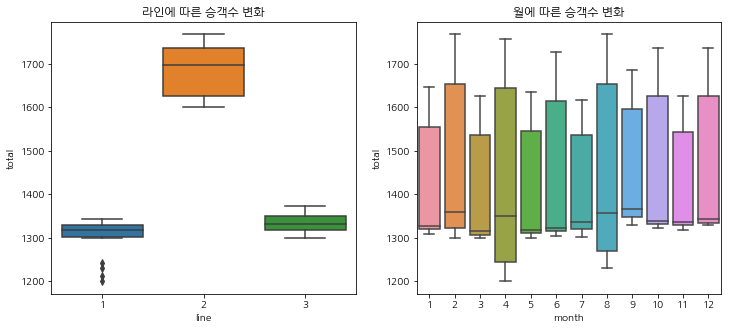

In [183]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))

sns.boxplot(data=d9, x='line', y='total', ax=ax[0])
ax[0].set_title('라인에 따른 승객수 변화')

sns.boxplot(data=d9, x='month', y='total', ax=ax[1])
ax[1].set_title('월에 따른 승객수 변화')
plt.show()

- 라인: 라인 2와 나머지 라인 간에는 승객 수의 차이가 확연하지만, 1-3라인 간에는 모호하다.  
- 월(중앙값 기준): 각 월 변화에 따라 승객수가 차이가 있어 보이지만 편차가 크며 구분이 쉽지 않다.